In [1]:
import pandas as pd

df_final = pd.read_parquet("data/xg_dataset_oof.parquet")
#candidates = joblib.load("candidates.pkl")
print("✅ df_final reloaded")

✅ df_final reloaded


In [2]:
df_final.columns

Index(['shot_id', 'id', 'index', 'match_id_x', 'competition_id_x', 'season_id',
       'period', 'timestamp', 'minute', 'second', 'duration', 'possession',
       'related_events', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'player_id', 'player_name', 'position_id',
       'position_name', 'location', 'x', 'y', 'shot_statsbomb_xg',
       'shot_end_location', 'end_x', 'end_y', 'shot_first_time',
       'shot_technique_id', 'shot_technique_name', 'shot_body_part_id',
       'shot_body_part_name', 'shot_type_id', 'shot_type_name',
       'shot_outcome_id', 'shot_outcome_name', 'under_pressure',
       'shot_key_pass_id', 'shot_aerial_won', 'shot_one_on_one',
       'shot_deflected', 'shot_open_goal', 'shot_saved_off_target',
       'shot_saved_to_post', 'shot_redirect', 'shot_follows_dribble',
       'shot_kick_off', 'off_camera', 'out', 'is_goal',
       'preferred_foot_inferred', 'p

In [3]:
df_final["season_id"].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: season_id, dtype: object

In [4]:
# Create a binary column for the real goal
df_final["goal"] = (df_final["shot_outcome_name"] == "Goal").astype(int)

# Group by match and team
df_match_team = (
    df_final
    .groupby(["match_id", "team_name"], as_index=False)
    .agg(
        xG_sum=("xG_oof", "sum"),
        goals=("goal", "sum"),
        n_shots=("xG_oof", "count"),
    )
)


In [5]:
df_match_team

,match_id,team_name,xG_sum,goals,n_shots
0,7430,North Carolina Courage,1.978849,4,17
1,7430,Washington Spirit,1.275335,2,8
2,7443,OL Reign,1.880929,3,13
3,7443,Portland Thorns,3.589765,2,24
4,7444,Chicago Red Stars,0.740094,1,8
...,...,...,...,...,...
5913,3943043,Spain,1.238682,2,16
5914,3943076,Canada,5.346318,5,19
5915,3943076,Uruguay,4.037971,6,16
5916,3943077,Argentina,1.029555,1,11


In [6]:
df_match_team["error"] = df_match_team["xG_sum"] - df_match_team["goals"]

df_match_team["error"].abs().mean()

np.float64(0.7576357805891409)

In [7]:
# Assumes these columns ready
# df_match_team: [match_id, team_name, xG_sum, goals, n_shots]

# 1) Totals per match
match_totals = (
    df_match_team
    .groupby("match_id", as_index=False)[["xG_sum", "goals"]]
    .sum()
    .rename(columns={"xG_sum": "xG_match_sum", "goals": "goals_match_sum"})
)

# 2) Add totals to each row (team)
df_mt = df_match_team.merge(match_totals, on="match_id", how="left")

# 3) Get the opponent's values ​​by difference
df_mt["opp_xG_sum"] = df_mt["xG_match_sum"] - df_mt["xG_sum"]
df_mt["opp_goals"]  = df_mt["goals_match_sum"] - df_mt["goals"]

# 4) Differences (each team's perspective)
df_mt["xG_diff_team"]   = df_mt["xG_sum"]   - df_mt["opp_xG_sum"]
df_mt["goal_diff_team"] = df_mt["goals"]    - df_mt["opp_goals"]

MATCH_COL = "match_id"
TEAM_COL  = "team_name"

df_ord = df_match_team.sort_values([MATCH_COL, TEAM_COL]).copy()
df_ord["ab_idx"] = df_ord.groupby(MATCH_COL).cumcount()

A = (df_ord[df_ord["ab_idx"] == 0]
     [[MATCH_COL, TEAM_COL, "xG_sum", "goals"]]
     .rename(columns={TEAM_COL:"team_A","xG_sum": "xG_A", "goals": "goals_A"}))

B = (df_ord[df_ord["ab_idx"] == 1]
     [[MATCH_COL, TEAM_COL, "xG_sum", "goals"]]
     .rename(columns={TEAM_COL:"team_B","xG_sum": "xG_B", "goals": "goals_B"}))

df_home_away = (A.merge(B, on=MATCH_COL, how="inner")
                  .assign(
                      xG_diff   = lambda d: d["xG_A"] - d["xG_B"],
                      goal_diff = lambda d: d["goals_A"] - d["goals_B"]
                  ))


# 6) Synthetic metrics
import numpy as np
acc = (np.sign(df_home_away["xG_diff"]) == np.sign(df_home_away["goal_diff"])).mean()
corr = df_home_away[["xG_diff", "goal_diff"]].corr().iloc[0,1]

print(f"Correlazione xG_diff vs goal_diff: {corr:.3f}")
print(f"% match 'predetti' dagli xG: {acc:.1%}")


Correlazione xG_diff vs goal_diff: 0.710
% match 'predetti' dagli xG: 61.1%


In [8]:
df_home_away["xG_diff"].describe()

count    2958.000000
mean        0.284249
std         1.471382
min        -5.745705
25%        -0.611728
50%         0.224129
75%         1.142051
max         7.111214
Name: xG_diff, dtype: float64

In [9]:
df_home_away

,match_id,team_A,xG_A,goals_A,team_B,xG_B,goals_B,xG_diff,goal_diff
0,7430,North Carolina Courage,1.978849,4,Washington Spirit,1.275335,2,0.703514,2
1,7443,OL Reign,1.880929,3,Portland Thorns,3.589765,2,-1.708836,1
2,7444,Chicago Red Stars,0.740094,1,North Carolina Courage,2.435871,1,-1.695777,0
3,7445,Utah Royals,0.845233,2,Washington Spirit,0.922957,0,-0.077724,2
4,7451,North Carolina Courage,2.033903,1,Washington Spirit,0.820693,0,1.213209,1
...,...,...,...,...,...,...,...,...,...
2953,3942819,England,1.141363,2,Netherlands,0.323959,1,0.817403,1
2954,3942852,Colombia,1.436105,1,Uruguay,0.955146,0,0.480958,1
2955,3943043,England,0.404001,1,Spain,1.238682,2,-0.834681,-1
2956,3943076,Canada,5.346318,5,Uruguay,4.037971,6,1.308347,-1


In [10]:
df = df_home_away.copy()

# Target: actual result (1 = win, 0 = draw, -1 = loss)
df["result"] = np.sign(df["goal_diff"]).astype(int)

# Feature: xG difference
df["xG_sum"] = df["xG_A"] +  df["xG_B"]          # match intensity

X = df[["xG_A", "xG_B", "xG_diff", "xG_sum"]]
y = df["result"]       # target



In [11]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


X_df = X.copy()                     
y_arr = np.asarray(y)               

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(X_df), dtype=int)

for train_idx, test_idx in cv.split(X_df, y_arr):
    # row selection with .iloc
    X_train = X_df.iloc[train_idx].values
    X_test  = X_df.iloc[test_idx].values
    y_train = y_arr[train_idx]

    clf = LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        class_weight="balanced"
    )

    clf.fit(X_train, y_train)
    oof_pred[test_idx] = clf.predict(X_test)

# assigns OOF predictions to the original dataframe
df.loc[X_df.index, "pred_result"] = oof_pred

# honest metrics (all out of sample)
print(f"OOF accuracy: {accuracy_score(y_arr, oof_pred):.3f}\n")

print("Confusion matrix (OOF):")
print(confusion_matrix(y_arr, oof_pred, labels=[-1,0,1]))

print("\nClassification report (OOF):")
print(classification_report(
    y_arr,
    oof_pred,
    labels=[-1,0,1],
    target_names=["Loss (-1)", "Draw (0)", "Win (+1)"],
    digits=3
))


OOF accuracy: 0.589

Confusion matrix (OOF):
[[578 246 105]
 [197 334 176]
 [124 367 831]]

Classification report (OOF):
              precision    recall  f1-score   support

   Loss (-1)      0.643     0.622     0.632       929
    Draw (0)      0.353     0.472     0.404       707
    Win (+1)      0.747     0.629     0.683      1322

    accuracy                          0.589      2958
   macro avg      0.581     0.574     0.573      2958
weighted avg      0.620     0.589     0.600      2958



c:\Users\lucar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

Accuracy totale: 0.589


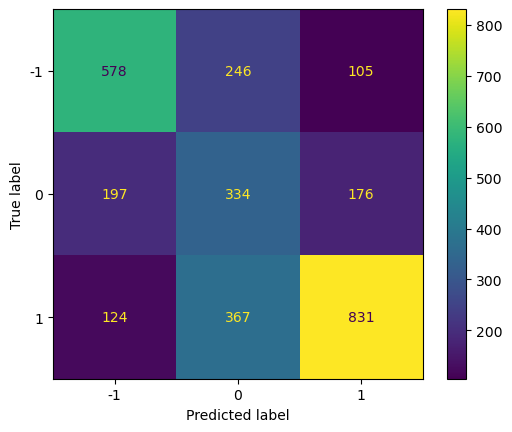

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y, df["pred_result"])
print(f"Accuracy totale: {acc:.3f}")

ConfusionMatrixDisplay.from_predictions(y, df["pred_result"])


In [13]:
print(classification_report(y, df["pred_result"], target_names=["Loss (-1)", "Draw (0)", "Win (+1)"]))


              precision    recall  f1-score   support

   Loss (-1)       0.64      0.62      0.63       929
    Draw (0)       0.35      0.47      0.40       707
    Win (+1)       0.75      0.63      0.68      1322

    accuracy                           0.59      2958
   macro avg       0.58      0.57      0.57      2958
weighted avg       0.62      0.59      0.60      2958



In [14]:
df["result"].value_counts(normalize=True)


result
 1    0.446924
-1    0.314064
 0    0.239013
Name: proportion, dtype: float64

In [15]:
df["pred_result"].value_counts(normalize=True)


pred_result
 1.0    0.375930
 0.0    0.320149
-1.0    0.303922
Name: proportion, dtype: float64

In [16]:
df["xG_bin"] = pd.cut(df["xG_diff"], bins=[-5, -1, -0.5, 0, 0.5, 1, 5])
pd.crosstab(df["xG_bin"], df["result"], normalize="index").round(2)


result,-1,0,1
xG_bin,,,
"(-5.0, -1.0]",0.77,0.17,0.06
"(-1.0, -0.5]",0.52,0.31,0.16
"(-0.5, 0.0]",0.33,0.36,0.31
"(0.0, 0.5]",0.24,0.31,0.44
"(0.5, 1.0]",0.17,0.27,0.57
"(1.0, 5.0]",0.06,0.14,0.81


In [17]:
import pandas as pd
import numpy as np

# ==== 0) Basic Assumptions and Checks ====
# df_final: One shot per row, contains at least ['match_id','competition_name']
# df: One match per row, contains at least ['match_id','goal_diff','xG_A','xG_B','xG_diff','pred_result']

if "match_id" not in df:
    raise KeyError("df deve contenere 'match_id'.")

# bring competition into df (from df_final)
comp_map = df_final.groupby("match_id")["competition_name"].first()
df = df.merge(comp_map.rename("competition_name"), on="match_id", how="left")

# detects home/away team column names
candidates_home = ["team_home", "home_team", "home", "team_A", "HomeTeam"]
candidates_away = ["team_away", "away_team", "away", "team_B", "AwayTeam"]

def pick(colnames, candidates):
    for c in candidates:
        if c in colnames:
            return c
    return None

HOME_COL = pick(df.columns, candidates_home)
AWAY_COL = pick(df.columns, candidates_away)

if HOME_COL is None or AWAY_COL is None:
    raise KeyError(
        "Non trovo le colonne delle squadre in df. "
        "Rinomina o aggiungi una coppia tra: "
        f"home={candidates_home}, away={candidates_away}"
    )

# ==== 1) Actual and predicted points at MATCH level ====
# Real result (home team perspective): 1=home win, 0=draw, -1=away win
df["real_result"] = np.sign(df["goal_diff"]).astype(int)

def result_to_points(r):
    # 1 → 3; 0 → 1; -1 → 0
    return np.select([r == 1, r == 0, r == -1], [3, 1, 0]).astype(int)

# points for home_team
df["real_points_home"] = result_to_points(df["real_result"])
df["pred_points_home"] = result_to_points(df["pred_result"])

# points for away_team
df["real_points_away"] = result_to_points(-df["real_result"])
df["pred_points_away"] = result_to_points(-df["pred_result"])

# ==== 2) Bring everything “per team” (long) ====
home_long = (
    df[["match_id","competition_name", HOME_COL, "xG_A", "real_points_home", "pred_points_home"]]
    .rename(columns={
        HOME_COL: "team_name",
        "xG_A": "xG_sum",
        "real_points_home": "real_points",
        "pred_points_home": "pred_points"
    })
    .assign(is_home=1)
)

away_long = (
    df[["match_id","competition_name", AWAY_COL, "xG_B", "real_points_away", "pred_points_away"]]
    .rename(columns={
        AWAY_COL: "team_name",
        "xG_B": "xG_sum",
        "real_points_away": "real_points",
        "pred_points_away": "pred_points"
    })
    .assign(is_home=0)
)

df_mt = pd.concat([home_long, away_long], ignore_index=True)

# sanity check: each match must have 2 teams
sizes = df_mt.groupby("match_id").size()
if (sizes != 2).any():
    print("⚠️ Warning: Matches found with != 2 teams. Distribution:", sizes.value_counts().to_dict())

# ==== 3) Rankings by competition ====
league_tables = {}

for comp, g in df_mt.groupby("competition_name"):
    matches_per_team = (
        g.groupby("team_name", as_index=False)["match_id"]
         .nunique()
         .rename(columns={"match_id": "n_matches"})
    )

    # Sums per team
    sums = (
        g.groupby("team_name", as_index=False)
         .agg(
             xG_total=("xG_sum","sum"),
             real_pts=("real_points","sum"),
             pred_pts=("pred_points","sum")
         )
    )

    table = (
        matches_per_team
        .merge(sums, on="team_name", how="left")
        .assign(
            pts_per_game       = lambda d: d["real_pts"] / d["n_matches"].clip(lower=1),
            pred_pts_per_game  = lambda d: d["pred_pts"] / d["n_matches"].clip(lower=1),
            diff               = lambda d: d["pred_pts"] - d["real_pts"],
            rank_real          = lambda d: d["real_pts"].rank(method="dense", ascending=False).astype(int),
            rank_pred          = lambda d: d["pred_pts"].rank(method="dense", ascending=False).astype(int),
            rank_diff          = lambda d: d["rank_real"] - d["rank_pred"]
        )
        .sort_values(["real_pts","pred_pts"], ascending=[False, False])
        .reset_index(drop=True)
    )

    league_tables[comp] = table

# ==== 4) Control output ====
print("Competizioni trovate:", list(league_tables.keys())[:10])
sample_comp = next(iter(league_tables.keys()))
print(f"\nEsempio classifica — {sample_comp}")
display(league_tables[sample_comp].head(10))


Competizioni trovate: ['1. Bundesliga', 'African Cup of Nations', 'Champions League', 'Copa America', 'Copa del Rey', 'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league', 'La Liga', 'Liga Profesional']

Esempio classifica — 1. Bundesliga


,team_name,n_matches,xG_total,real_pts,pred_pts,pts_per_game,pred_pts_per_game,diff,rank_real,rank_pred,rank_diff
0,Bayer Leverkusen,68,128.350742,144,130,2.117647,1.911765,-14,1,1,0
1,Bayern Munich,36,80.508257,89,86,2.472222,2.388889,-3,2,2,0
2,Borussia Dortmund,36,80.973087,80,83,2.222222,2.305556,3,3,3,0
3,Borussia Mönchengladbach,36,53.891710,58,46,1.611111,1.277778,-12,4,9,-5
4,Schalke 04,34,46.167647,52,50,1.529412,1.470588,-2,5,7,-2
5,FSV Mainz 05,36,47.001178,51,41,1.416667,1.138889,-10,6,10,-4
6,Hertha Berlin,34,36.563066,48,46,1.411765,1.352941,-2,7,9,-2
7,Wolfsburg,36,47.245393,45,55,1.250000,1.527778,10,8,5,3
8,FC Köln,36,42.578478,43,36,1.194444,1.000000,-7,9,12,-3
9,Darmstadt 98,36,35.967716,41,33,1.138889,0.916667,-8,10,13,-3


In [18]:
league_tables.keys()
# ['Champions League Men', 'Champions League Women', ...]


dict_keys(['1. Bundesliga', 'African Cup of Nations', 'Champions League', 'Copa America', 'Copa del Rey', 'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league', 'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer', 'NWSL', 'North American League', 'Premier League', 'Serie A', 'UEFA Euro', 'UEFA Europa League'])

In [19]:
comp = "Serie A"
league_tables[comp].head(20)


,team_name,n_matches,xG_total,real_pts,pred_pts,pts_per_game,pred_pts_per_game,diff,rank_real,rank_pred,rank_diff
0,Juventus,39,63.798986,89,80,2.282051,2.051282,-9,1,2,-1
1,Napoli,39,68.252879,85,80,2.179487,2.051282,-5,2,2,0
2,AS Roma,38,65.094990,81,81,2.131579,2.131579,0,3,1,2
3,Inter Milan,38,51.296653,67,54,1.763158,1.421053,-13,4,5,-1
4,Fiorentina,38,55.111347,64,64,1.684211,1.684211,0,5,3,2
5,Sassuolo,38,45.707026,60,52,1.578947,1.368421,-8,6,6,0
6,AC Milan,38,53.871207,57,56,1.500000,1.473684,-1,7,4,3
7,Lazio,38,49.481673,55,54,1.447368,1.421053,-1,8,5,3
8,Chievo,38,37.374111,49,34,1.289474,0.894737,-15,9,12,-3
9,Genoa,38,42.192683,48,48,1.263158,1.263158,0,10,7,3


In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================================
# 1️⃣ Let's assume a DataFrame df_home_away with columns:
# ['match_id', 'xG_A', 'xG_B', 'goals_A', 'goals_B']
# ==========================================================

# Add differences and derived features
df_match = df_home_away.copy()
df_match["xG_diff"] = df_match["xG_A"] - df_match["xG_B"]
df_match["abs_xG_diff"] = df_match["xG_diff"].abs()
df_match["xG_sum"] = df_match["xG_A"] + df_match["xG_B"]

# Labels: -1 = loss, 0 = draw, 1 = win (for A)
df_match["result"] = np.sign(df_match["goals_A"] - df_match["goals_B"]).astype(int)

# minimal features
f_draw = ["abs_xG_diff", "xG_sum"]   # draw vs non-draw
f_win  = ["xG_diff", "xG_sum"]       # win vs loss

# ==========================================================
# 2️⃣ 2-stage model with calibration
# ==========================================================
clf_draw = CalibratedClassifierCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=500),
    method="isotonic", cv=3
)
clf_win = CalibratedClassifierCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=500),
    method="isotonic", cv=3
)

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y = df_match["result"].values          # -1, 0, 1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF storage
p_draw_oof  = np.zeros(len(df_match))
p_win_oof   = np.zeros(len(df_match))
p_loss_oof  = np.zeros(len(df_match))
y_pred_oof  = np.zeros(len(df_match), dtype=int)

for tr_idx, va_idx in cv.split(df_match, y):
    df_tr = df_match.iloc[tr_idx].copy()
    df_va = df_match.iloc[va_idx].copy()

    # ===== 1: Draw vs Non-Draw (train on train folds) =====
    y_draw_tr = (df_tr["result"] == 0).astype(int)
    clf_draw.fit(df_tr[f_draw], y_draw_tr)

    # pred draw on validation
    p_draw_va = clf_draw.predict_proba(df_va[f_draw])[:, 1]

    # ===== 2: Win vs Loss (only Non-Draw in train) =====
    mask_nd_tr = df_tr["result"] != 0
    y_win_tr = (df_tr.loc[mask_nd_tr, "result"] == 1).astype(int)
    clf_win.fit(df_tr.loc[mask_nd_tr, f_win], y_win_tr)

    # pred win_vs_loss on validation (we still use all the lines of va)
    p_win_nd_va = clf_win.predict_proba(df_va[f_win])[:, 1]

    # ===== Combination of probabilities =====
    p_win_va  = (1 - p_draw_va) * p_win_nd_va
    p_loss_va = 1 - p_draw_va - p_win_va

    # save OOF
    p_draw_oof[va_idx] = p_draw_va
    p_win_oof[va_idx]  = p_win_va
    p_loss_oof[va_idx] = p_loss_va

    # predicted class
    probs_va = np.vstack([p_loss_va, p_draw_va, p_win_va]).T
    y_pred_oof[va_idx] = np.array([-1, 0, 1])[probs_va.argmax(axis=1)]

# ===== OOF Metrics =====
print(f"Accuracy OOF: {accuracy_score(y, y_pred_oof):.3f}\n")

print("Confusion Matrix (OOF):")
print(confusion_matrix(y, y_pred_oof, labels=[-1, 0, 1]))

print("\nClassification Report (OOF):")
print(classification_report(
    y, y_pred_oof,
    labels=[-1, 0, 1],
    target_names=["Loss (-1)", "Draw (0)", "Win (+1)"],
    digits=3
))

# save probs in df_match
df_match["p_loss_ev"]  = p_loss_oof
df_match["p_draw_ev"]  = p_draw_oof
df_match["p_win_ev"]   = p_win_oof
df_match["pred_result_ev"] = y_pred_oof


Accuracy OOF: 0.626

Confusion Matrix (OOF):
[[ 636  110  183]
 [ 239  150  318]
 [ 141  115 1066]]

Classification Report (OOF):
              precision    recall  f1-score   support

   Loss (-1)      0.626     0.685     0.654       929
    Draw (0)      0.400     0.212     0.277       707
    Win (+1)      0.680     0.806     0.738      1322

    accuracy                          0.626      2958
   macro avg      0.569     0.568     0.556      2958
weighted avg      0.596     0.626     0.601      2958



In [21]:
df_match

,match_id,team_A,xG_A,goals_A,team_B,xG_B,goals_B,xG_diff,goal_diff,abs_xG_diff,xG_sum,result,p_loss_ev,p_draw_ev,p_win_ev,pred_result_ev
0,7430,North Carolina Courage,1.978849,4,Washington Spirit,1.275335,2,0.703514,2,0.703514,3.254184,1,0.174975,0.256791,0.568234,1
1,7443,OL Reign,1.880929,3,Portland Thorns,3.589765,2,-1.708836,1,1.708836,5.470694,1,0.906220,0.067876,0.025904,-1
2,7444,Chicago Red Stars,0.740094,1,North Carolina Courage,2.435871,1,-1.695777,0,1.695777,3.175965,0,0.826759,0.141227,0.032014,-1
3,7445,Utah Royals,0.845233,2,Washington Spirit,0.922957,0,-0.077724,2,0.077724,1.768190,1,0.261429,0.407308,0.331264,0
4,7451,North Carolina Courage,2.033903,1,Washington Spirit,0.820693,0,1.213209,1,1.213209,2.854596,1,0.068447,0.229594,0.701959,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2953,3942819,England,1.141363,2,Netherlands,0.323959,1,0.817403,1,0.817403,1.465322,1,0.140004,0.301839,0.558158,1
2954,3942852,Colombia,1.436105,1,Uruguay,0.955146,0,0.480958,1,0.480958,2.391251,1,0.189004,0.291254,0.519743,1
2955,3943043,England,0.404001,1,Spain,1.238682,2,-0.834681,-1,0.834681,1.642684,-1,0.554352,0.282291,0.163357,-1
2956,3943076,Canada,5.346318,5,Uruguay,4.037971,6,1.308347,-1,1.308347,9.384290,-1,0.061866,0.010686,0.927448,1


In [22]:
from pathlib import Path

OUT = Path("data/derived")

df_match.to_parquet(OUT / "df_xG.parquet", index=False)

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from scipy.stats import spearmanr, kendalltau, pearsonr

rows = []

for comp, table in league_tables.items():
    mae = mean_absolute_error(table["real_pts"], table["pred_pts"])
    rmse = root_mean_squared_error(table["real_pts"], table["pred_pts"])
    rho, _ = spearmanr(table["rank_real"], table["rank_pred"])
    tau, _ = kendalltau(table["rank_real"], table["rank_pred"])
    r, _   = pearsonr(table["real_pts"], table["pred_pts"])

    rows.append({
        "competition": comp,
        "MAE_pts": mae,
        "RMSE_pts": rmse,
        "Spearman_rho": rho,
        "Kendall_tau": tau,
        "Pearson_r": r
    })

metrics_df = pd.DataFrame(rows).sort_values("Spearman_rho", ascending=False).reset_index(drop=True)
display(metrics_df.head(30))



C:\Users\lucar\AppData\Local\Temp\ipykernel_12380\4041947378.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(table["rank_real"], table["rank_pred"])
C:\Users\lucar\AppData\Local\Temp\ipykernel_12380\4041947378.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _   = pearsonr(table["real_pts"], table["pred_pts"])


,competition,MAE_pts,RMSE_pts,Spearman_rho,Kendall_tau,Pearson_r
0,FIFA U20 World Cup,0.000000,0.000000,1.000000,1.000000,1.000000
1,North American League,0.000000,0.000000,1.000000,1.000000,1.000000
2,Premier League,4.896552,6.480741,0.960558,0.861904,0.983846
3,La Liga,4.585366,7.251577,0.941433,0.841496,0.999406
4,African Cup of Nations,1.833333,2.629956,0.899913,0.767470,0.810773
5,Ligue 1,6.407407,8.838049,0.887048,0.779415,0.982375
6,Copa America,1.687500,2.106537,0.879464,0.766527,0.932895
7,FIFA World Cup,2.840909,3.780933,0.875217,0.744968,0.933865
8,Indian Super league,4.909091,6.310165,0.833715,0.660578,0.839465
9,UEFA Euro,3.448276,4.697762,0.820910,0.646207,0.818809


In [24]:
import numpy as np
import pandas as pd

# Add competition_name from df_final (one shot per line) to df_home_away (one match per line)
comp_map = df_final.groupby("match_id")["competition_name"].first()
df_home_away = df_home_away.merge(
    comp_map.rename("competition_name"),
    on="match_id",
    how="left"
)

df = df_home_away.copy()
df["xG_diff"]   = df["xG_A"] - df["xG_B"]
df["goal_diff"] = df["goal_diff"]  # already present: >0 A wins, <0 B wins

# a) "clean" version: I exclude matches with even xG (very rare)
mask_neq = df["xG_diff"] != 0
acc_overall = (np.sign(df.loc[mask_neq, "xG_diff"]) == np.sign(df.loc[mask_neq, "goal_diff"])).mean()

# b) optional: if xG equal, count them as 0.5 "correct" if it's a real draw
def xg_winner_hits(row):
    if row.xG_diff > 0:   return 1.0 if row.goal_diff > 0 else 0.0
    if row.xG_diff < 0:   return 1.0 if row.goal_diff < 0 else 0.0
    # xG even: half a point if the result is also even
    return 0.5 if row.goal_diff == 0 else 0.0

hit = df.apply(xg_winner_hits, axis=1)
acc_adjusted = hit.mean()

print(f"% vittorie quando 'vince' negli xG (escludendo xG pari): {acc_overall:.1%}")
print(f"% 'correttezza' con gestione xG=pari (0.5 sui pareggi):  {acc_adjusted:.1%}")

# Breakdown per competition
by_comp = (
    df.assign(hit_adj=hit)
      .query("xG_diff != 0")
      .assign(hit_neq=(np.sign(df["xG_diff"])==np.sign(df["goal_diff"])))
      .groupby("competition_name")
      .agg(pct_hit_neq=("hit_neq","mean"), pct_hit_adj=("hit_adj","mean"), n=("match_id","count"))
      .sort_values("pct_hit_neq", ascending=False)
)
display(by_comp.head(10))


% vittorie quando 'vince' negli xG (escludendo xG pari): 61.1%
% 'correttezza' con gestione xG=pari (0.5 sui pareggi):  61.1%


,pct_hit_neq,pct_hit_adj,n
competition_name,,,
Liga Profesional,1.000000,1.000000,2
FIFA U20 World Cup,1.000000,1.000000,1
UEFA Europa League,1.000000,1.000000,3
North American League,1.000000,1.000000,1
Champions League,0.777778,0.777778,18
Copa America,0.687500,0.687500,32
La Liga,0.687428,0.687428,867
Copa del Rey,0.666667,0.666667,3
Major League Soccer,0.666667,0.666667,6


In [25]:
# Filter real draws
draws = df.query("goal_diff == 0").copy()
draws["xG_sum"] = draws["xG_A"] + draws["xG_B"]
draws["abs_xG_diff"] = draws["xG_A"] - draws["xG_B"]
draws["abs_xG_diff"] = draws["abs_xG_diff"].abs()

# Global results
summary_draws = pd.DataFrame({
    "xG_A_median": [draws["xG_A"].median()],
    "xG_B_median": [draws["xG_B"].median()],
    "xG_sum_median": [draws["xG_sum"].median()],
    "|xG_diff|_median": [draws["abs_xG_diff"].median()],
})
print("Profili tipici (mediane) dei pareggi:")
display(summary_draws)

percentili = draws[["xG_A","xG_B","xG_sum","abs_xG_diff"]].quantile([0.1,0.25,0.5,0.75,0.9])
display(percentili)

# Breakdown per competition (median)
by_comp_draws = (
    draws.groupby("competition_name")[["xG_A","xG_B","xG_sum","abs_xG_diff"]]
         .median()
         .rename(columns={"abs_xG_diff":"|xG_diff|"})
         .sort_values("xG_sum")
)
display(by_comp_draws.head(10))


Profili tipici (mediane) dei pareggi:


,xG_A_median,xG_B_median,xG_sum_median,|xG_diff|_median
0,1.035692,1.023013,2.111801,0.592176


,xG_A,xG_B,xG_sum,abs_xG_diff
0.10,0.399287,0.340952,1.163493,0.098937
0.25,0.621010,0.608042,1.559696,0.284399
0.50,1.035692,1.023013,2.111801,0.592176
0.75,1.567259,1.463172,2.862472,1.066498
0.90,2.131593,1.976872,3.647808,1.554679


,xG_A,xG_B,xG_sum,|xG_diff|
competition_name,,,,
Major League Soccer,0.601472,0.570511,1.171983,0.030960
Copa America,0.730851,0.530117,1.385422,0.386793
UEFA Euro,0.929662,0.924209,1.880275,0.746209
NWSL,0.961389,0.953178,1.904895,0.753591
Serie A,0.928662,0.957064,1.964759,0.549900
African Cup of Nations,0.857163,0.860813,1.983924,0.667832
Ligue 1,0.888646,1.024751,2.093564,0.574276
FIFA World Cup,0.899409,0.912915,2.111801,0.592785
Premier League,1.212318,1.011471,2.170815,0.673315


In [26]:
from sklearn.linear_model import LogisticRegression

X = df[["xG_A","xG_B"]].to_numpy()
y = (df["goal_diff"] > 0).astype(int).to_numpy()  # 1=win A, 0=draw/loss

logit = LogisticRegression(max_iter=1000).fit(X, y)
coef_A, coef_B = logit.coef_[0]  # coef_B expected < 0
print(f"Coef xG_A: {coef_A:.3f}   Coef xG_B: {coef_B:.3f}  (intercetta: {logit.intercept_[0]:.3f})")

# Odds ratio for +0.1 xG (1/10 of xG)
OR_A = np.exp(0.1*coef_A)
OR_B = np.exp(0.1*coef_B)
print(f"OR(+0.1 xG propri): {OR_A:.3f}    OR(+0.1 xG avversari): {OR_B:.3f}")


Coef xG_A: 1.277   Coef xG_B: -1.082  (intercetta: -0.859)
OR(+0.1 xG propri): 1.136    OR(+0.1 xG avversari): 0.897


In [27]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

rows = []

for comp, g in df_home_away.groupby("competition_name"):
    # Avoid leagues that are too small (less than 30 matches)
    if len(g) < 30:
        continue

    # Build features and target
    X = g[["xG_A", "xG_B"]].to_numpy()
    y = (g["goal_diff"] > 0).astype(int).to_numpy()  # 1 = win team A

    try:
        logit = LogisticRegression(max_iter=1000).fit(X, y)
        coef_A, coef_B = logit.coef_[0]
        intercept = logit.intercept_[0]
        # Odds ratio for +0.1 xG
        OR_A = np.exp(0.1 * coef_A)
        OR_B = np.exp(0.1 * coef_B)
        rows.append({
            "competition": comp,
            "n_matches": len(g),
            "coef_xG_A": coef_A,
            "coef_xG_B": coef_B,
            "OR(+0.1 xG_A)": OR_A,
            "OR(+0.1 xG_B)": OR_B,
            "intercept": intercept
        })
    except Exception as e:
        print(f"⚠️ Problem with {comp}: {e}")

df_logit_comp = pd.DataFrame(rows).sort_values("coef_xG_A", ascending=False).reset_index(drop=True)
display(df_logit_comp.head(10))


,competition,n_matches,coef_xG_A,coef_xG_B,OR(+0.1 xG_A),OR(+0.1 xG_B),intercept
0,1. Bundesliga,340,1.439115,-1.097827,1.154782,0.896029,-0.891473
1,Ligue 1,435,1.414621,-1.077486,1.151957,0.897853,-1.051459
2,La Liga,867,1.336388,-1.222765,1.142980,0.884904,-0.737315
3,Premier League,418,1.278311,-0.929757,1.136361,0.911216,-1.336722
4,Serie A,381,1.175450,-0.996972,1.124732,0.905111,-0.885893
5,Indian Super league,115,1.083602,-0.552330,1.114449,0.946265,-1.319269
6,UEFA Euro,102,1.005099,-0.822826,1.105735,0.921012,-0.965193
7,Copa America,32,0.958158,-0.975136,1.100556,0.907090,-0.234912
8,NWSL,36,0.926421,-0.666548,1.097069,0.935518,-0.315413
9,FIFA World Cup,146,0.908291,-0.596635,1.095082,0.942081,-0.568188


In [28]:
from pathlib import Path

OUT = Path("data/derived")

metrics_df.to_parquet(OUT / "metrics_xG_df.parquet", index=False)